💾 Generating Mitigation Report (Including 128K)...
✅ Saved: ../reports/bias_mitigation_metrics.csv and fragmentation_chart.png


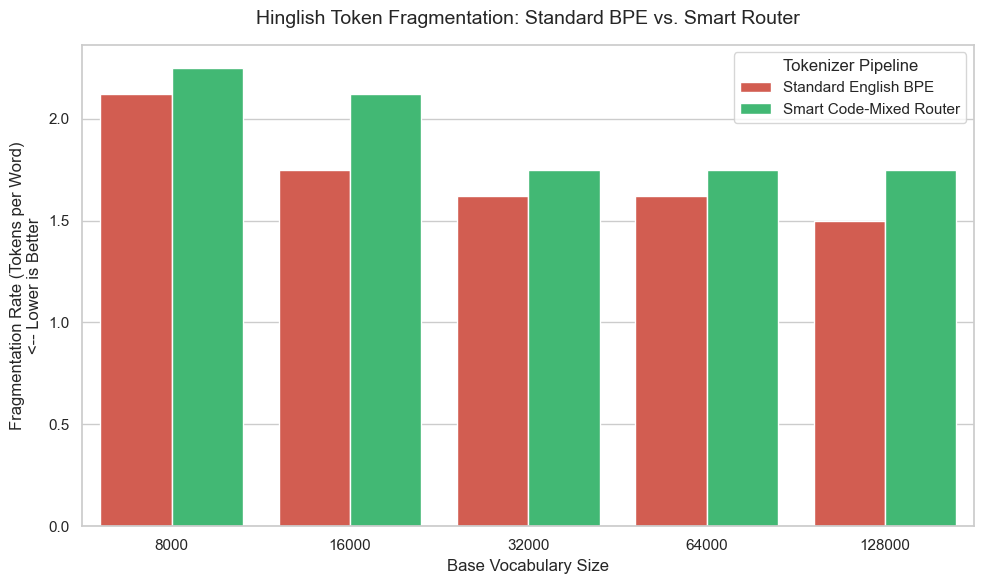

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bpe import BPETokenizer

print("💾 Generating Mitigation Report (Including 128K)...")

class CodeMixedTokenizer:
    def __init__(self, primary_bpe, fallback_bpe):
        self.primary = primary_bpe
        self.fallback = fallback_bpe
        self.known_english = set([k.replace('</w>', '') for k in self.primary.vocab.keys()])

    def encode(self, text):
        words = text.split()
        final_tokens = []
        for word in words:
            clean_word = word.lower().strip('.,!?')
            if clean_word in self.known_english:
                final_tokens.extend(self.primary.encode(word + " ")['tokens'])
            else:
                tokens = self.fallback.encode(word + " ")['tokens']
                final_tokens.extend([f"[MIX]_{t}" for t in tokens])
        return {"tokens": final_tokens}

test_sentence = "Main market ja raha hu fresh vegetables kharidne."
word_count = len(test_sentence.split())
target_sizes = [8000, 16000, 32000, 64000, 128000]
final_metrics = []

for size in target_sizes:
    eng_bpe = BPETokenizer()
    eng_bpe.load(f'../vocabs/bpe_{size}.json')
    router_tokenizer = CodeMixedTokenizer(eng_bpe, bbpe)
    
    std_tokens = eng_bpe.encode(test_sentence)['tokens']
    final_metrics.append({
        "Vocabulary Size": size,
        "Tokenizer Model": "Standard English BPE",
        "Tokens per Word": round(len(std_tokens) / word_count, 2)
    })
    
    router_tokens = router_tokenizer.encode(test_sentence)['tokens']
    final_metrics.append({
        "Vocabulary Size": size,
        "Tokenizer Model": "Smart Code-Mixed Router",
        "Tokens per Word": round(len(router_tokens) / word_count, 2)
    })

df_final = pd.DataFrame(final_metrics)
df_final.to_csv('../reports/bias_mitigation_metrics.csv', index=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_final, x="Vocabulary Size", y="Tokens per Word", hue="Tokenizer Model", palette=["#e74c3c", "#2ecc71"])

plt.title("Hinglish Token Fragmentation: Standard BPE vs. Smart Router", fontsize=14, pad=15)
plt.ylabel("Fragmentation Rate (Tokens per Word)\n<-- Lower is Better", fontsize=12)
plt.xlabel("Base Vocabulary Size", fontsize=12)
plt.legend(title="Tokenizer Pipeline")

plt.tight_layout()
plt.savefig('../reports/fragmentation_chart.png', dpi=300)
print("✅ Saved: ../reports/bias_mitigation_metrics.csv and fragmentation_chart.png")
plt.show()